In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import requests
from io import StringIO
from datetime import timedelta, datetime
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.font_manager as fm
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'utils'))
from functions_visualization import *
font_path = "font-folder/Roboto-Regular.ttf"
font_path_bold = "font-folder/Roboto-Bold.ttf"
font_prop = fm.FontProperties(fname=font_path, size=20)
font_prop_legend = fm.FontProperties(fname=font_path, size=16)
font_prop_title = fm.FontProperties(fname=font_path_bold, size=22)
import matplotlib as mpl
mpl.rcParams['font.family'] = font_prop.get_name()
import warnings
import matplotlib
warnings.filterwarnings('ignore')
matplotlib.set_loglevel('error')


/Users/stefania/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df_surv =  pd.read_csv("../../../../input_data/target-data-age-stratification.csv")
df_surv = df_surv[(df_surv['target'] == 'inc hosp') & (df_surv['age_group'] == '65-130') & \
                    (df_surv['location'] >= 'US') & (df_surv['date'] >= '2024-11-22') & (df_surv['date'] <= '2025-03-29')]
df_surv = df_surv.sort_values(by='date')
df_surv

,date,location,observation,age_group,target
22725,2024-11-23,US,1572.0,65-130,inc hosp
22730,2024-11-30,US,2077.0,65-130,inc hosp
22735,2024-12-07,US,3122.0,65-130,inc hosp
22740,2024-12-14,US,4529.0,65-130,inc hosp
22745,2024-12-21,US,7556.0,65-130,inc hosp
22750,2024-12-28,US,14858.0,65-130,inc hosp
22755,2025-01-04,US,21984.0,65-130,inc hosp
22760,2025-01-11,US,17210.0,65-130,inc hosp
22765,2025-01-18,US,17547.0,65-130,inc hosp
22770,2025-01-25,US,21440.0,65-130,inc hosp


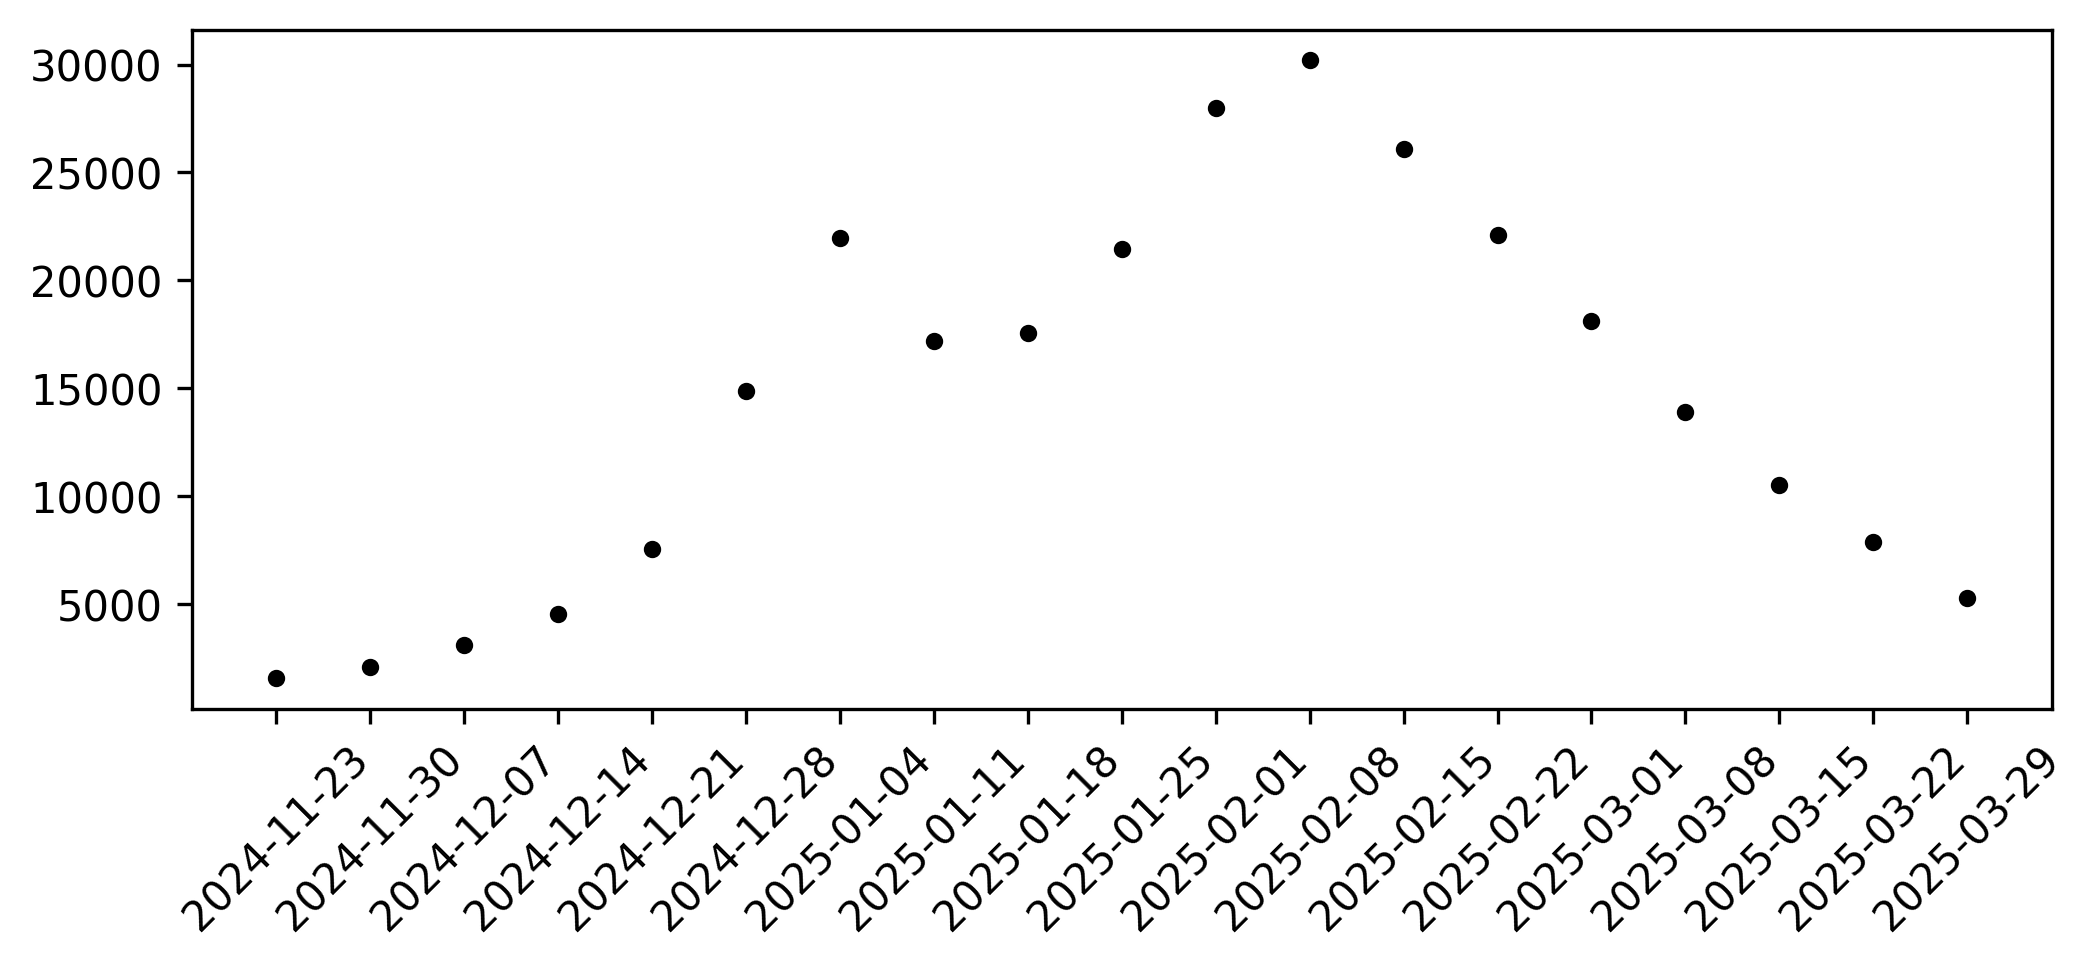

In [3]:
plt.figure(figsize=(8,3), dpi=300)
plt.scatter(df_surv['date'], df_surv['observation'], color = 'black', s=10)
plt.xticks(rotation=45)
plt.show()

In [3]:
def read_csv_from_github(url):
    """
    Reads a CSV file from a given GitHub URL and returns it as a pandas DataFrame.
    input:
        url = URL of the CSV file on GitHub
    output:
        df = DataFrame containing the CSV data
    """
    response = requests.get(url)
    if response.status_code == 200:
        csv_content = response.content.decode('utf-8')
        return pd.read_csv(StringIO(csv_content))
    else:
        print(f"Failed to fetch file. Status code: {response.status_code}, Message: {response.text}")
        return pd.DataFrame()
        
def loading_surveillance_eval(start_date, end_date, path_surv):
    """
    This function loads the surveillance data from a GitHub repository.
    input:
        start_date = start date for the data
        github_repo = GitHub repository name
        github_directory = directory in the GitHub repository
        surveillance_file = name of the surveillance file
        state = state to filter the data
        horizon_to_start = horizon to start the data
    output:
        df_surv_date_US = dataframe with the filtered surveillance data
    """
    df_surv = pd.read_csv(path_surv)

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    df_surv['date'] = pd.to_datetime(df_surv['date'])
    df_surv = df_surv[(df_surv['target'] == 'inc hosp') & (df_surv['age_group'] == '65-130')]
    # filter the dataframe to only include rows where the location is 'US' and the date is between start_date and ref_date
    df_surv_date_US = df_surv[(df_surv.location == 'US') & 
                            (df_surv.date >= start_date) & 
                            (df_surv.date <= end_date)]
    df_surv_date_US = df_surv_date_US.rename(columns={"observation": "hospitalizations"})
    df_surv_date_US = df_surv_date_US.sort_values(by='date')
    df_surv_date_US['horizon'] = np.arange(1, len(df_surv_date_US)+1)
    return df_surv_date_US

In [ ]:
state = 'US'
# Loading surveillance data for evaluation: last surveillance file
start_date = datetime(2024, 11, 23)  # Adjusted to the latest date in the surveillance data
end_date = datetime(2025, 5, 17)
path_surv =  "../../../../input_data/target-data-age-stratification.csv"
df_surv = loading_surveillance_eval(start_date, end_date, path_surv)
df_surv

,date,location,hospitalizations,age_group,target,horizon
22725,2024-11-23,US,1572.0,65-130,inc hosp,1
22730,2024-11-30,US,2077.0,65-130,inc hosp,2
22735,2024-12-07,US,3122.0,65-130,inc hosp,3
22740,2024-12-14,US,4529.0,65-130,inc hosp,4
22745,2024-12-21,US,7556.0,65-130,inc hosp,5
22750,2024-12-28,US,14858.0,65-130,inc hosp,6
22755,2025-01-04,US,21984.0,65-130,inc hosp,7
22760,2025-01-11,US,17210.0,65-130,inc hosp,8
22765,2025-01-18,US,17547.0,65-130,inc hosp,9
22770,2025-01-25,US,21440.0,65-130,inc hosp,10


In [ ]:
loss_function = 'wmape'
season = '2024-2025'
df_wis = pd.read_csv(f"../../output_data/performance_adaptive_agestrata/wis_performance_{loss_function}.csv")
df_mae = pd.read_csv(f"../../output_data/performance_adaptive_agestrata/mae_performance_{loss_function}.csv")
df_wis

,k_perc,week,wis_adaptive_ensemble2,wis_original_ensemble2,wis_rel_original2
0,5,2024-11-23,7568.682240,4768.647961,1.587176
1,5,2024-11-30,7862.203934,4941.808244,1.590957
2,5,2024-12-07,8187.080566,5125.126754,1.597440
3,5,2024-12-14,8321.071203,5311.092102,1.566734
4,5,2024-12-21,7941.546491,5495.633986,1.445065
...,...,...,...,...,...
115,75,2025-04-05,684.565611,928.839241,0.737012
116,75,2025-04-12,627.689858,779.944753,0.804788
117,75,2025-04-19,563.332366,691.365268,0.814811
118,75,2025-04-26,528.020950,629.443205,0.838870


Data format for plotting boxplots of different k values

In [8]:
# -------- WIS --------
df_melted_wis = df_wis.melt(id_vars=['k_perc'], value_vars=['wis_rel_original2'], 
                    var_name='metric', value_name='value')
df_melted_wis['k_perc'] = df_melted_wis['k_perc'].astype(str)
df_melted_wis

# MAE
df_melted_mae = df_mae.melt(id_vars=['k_perc'], value_vars=['mae_rel_original2'], 
                    var_name='metric', value_name='value')
df_melted_mae['k_perc'] = df_melted_mae['k_perc'].astype(str)
df_melted_mae

,k_perc,metric,value
0,5,mae_rel_original2,1.166382
1,5,mae_rel_original2,1.044454
2,5,mae_rel_original2,1.044768
3,5,mae_rel_original2,1.033012
4,5,mae_rel_original2,1.011923
...,...,...,...
115,75,mae_rel_original2,1.046610
116,75,mae_rel_original2,1.034848
117,75,mae_rel_original2,1.024909
118,75,mae_rel_original2,1.017793


Data format for plotting metrics in time (for k = 15,25,50 and separately in supplementary k=5,75)

In [9]:
df_surv.rename(columns={"date": "week"}, inplace=True)
df_wis_k_5, df_wis_k_15, df_wis_k_25, df_wis_k_50, df_wis_k_75 = get_wis_dataframes(df_wis, df_surv)
df_mae_k_5, df_mae_k_15, df_mae_k_25, df_mae_k_50, df_mae_k_75 = get_mae_dataframes(df_mae, df_surv)

Define colors palette and references

In [15]:
# Palette
palette = {
    '5': '#1d4f60',
    '15': '#2d7974',
    '25': '#4da284',
    '50': '#80c799',
    '75': '#c4e6c3'
}
color_swarm = '#103a43'
color_hosp = 'grey'
y_lim = [0.3, 1.7]

Visualization

findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not

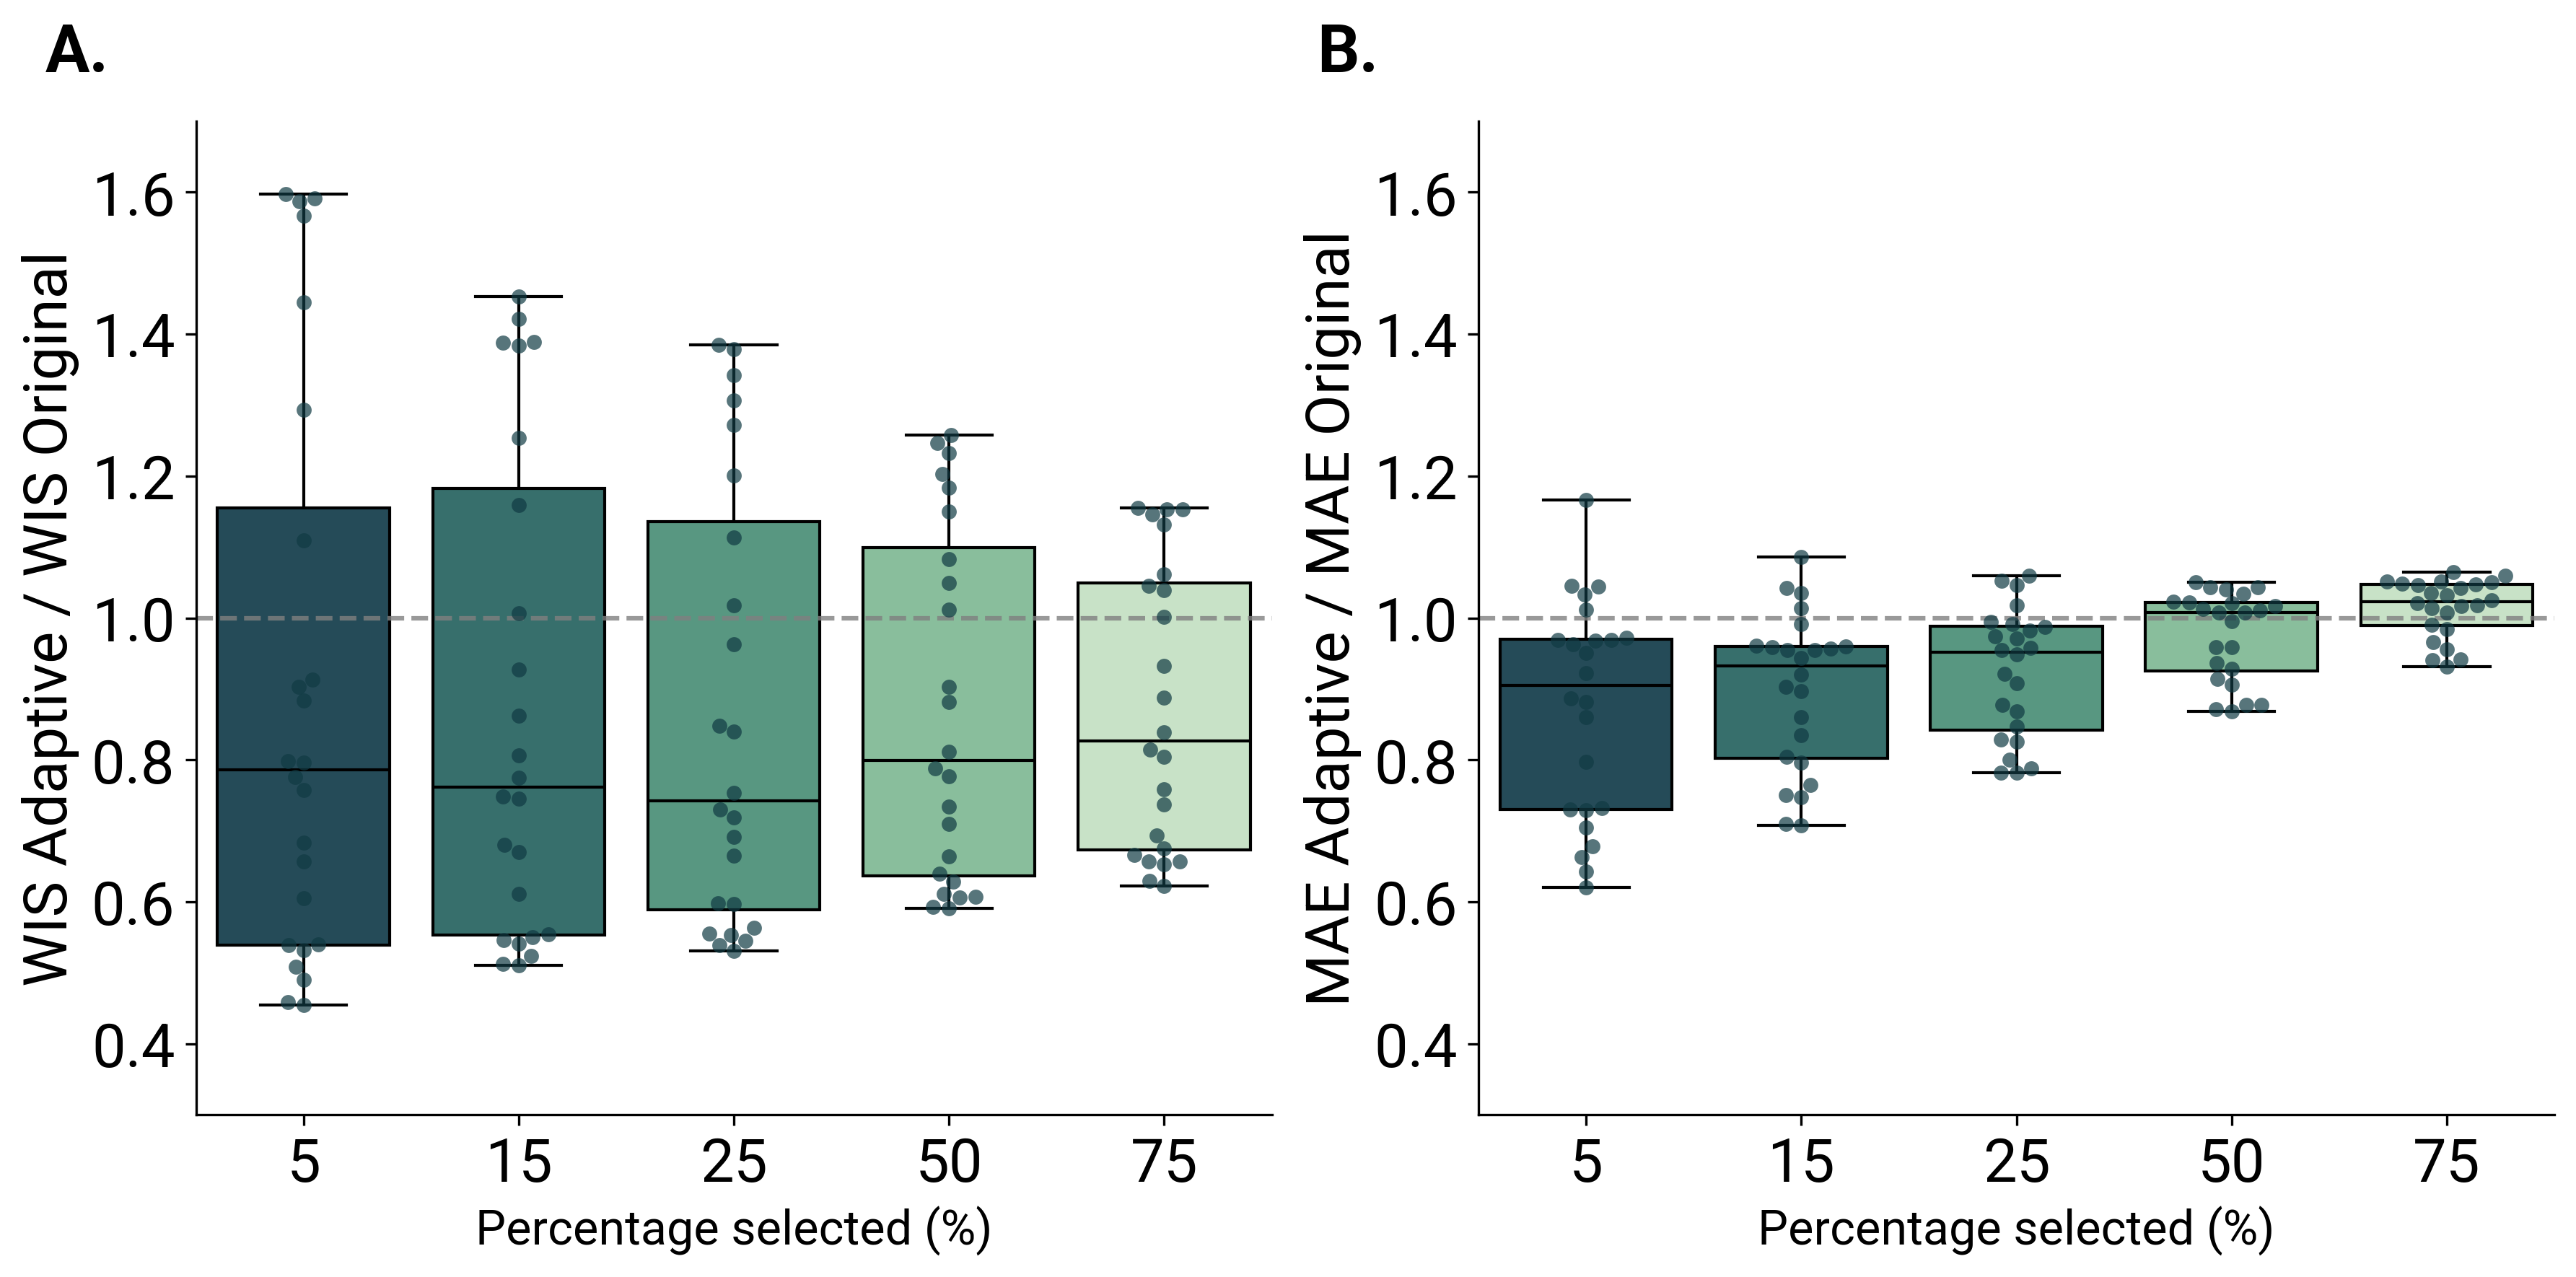

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# --- FIRST SUBPLOT (A): WIS ---
ax1 = axes[0]
sns.boxplot(data=df_melted_wis, x='k_perc', y='value', ax=ax1, palette=palette, showfliers=False,
            boxprops=dict(edgecolor='black', linewidth=1.0),
            whiskerprops=dict(color='black', linewidth=1.0),
            capprops=dict(color='black', linewidth=1.0),
            medianprops=dict(color='black', linewidth=1.0))
sns.swarmplot(data=df_melted_wis, x='k_perc', y='value', ax=ax1, color=color_swarm, size=5, alpha=0.7)
#sns.scatterplot(x=means_wis.index, y=means_wis.values, ax=ax1, color=color_swarm,
#                marker='s', s=100, zorder=5)
ax1.axhline(1, color='grey', linestyle='--', alpha=0.8)
ax1.set_xlabel('Percentage selected (%)', fontproperties=font_prop_legend)
ax1.set_ylabel('WIS Adaptive / WIS Original', fontproperties=font_prop)
ax1.text(-0.14, 1.05, 'A.', transform=ax1.transAxes, fontproperties=font_prop_title)
sns.despine(ax=ax1)

# --- SECOND SUBPLOT (B): MAE ---
ax2 = axes[1]
sns.boxplot(data=df_melted_mae, x='k_perc', y='value', ax=ax2, palette=palette, showfliers=False,
            boxprops=dict(edgecolor='black', linewidth=1.0),
            whiskerprops=dict(color='black', linewidth=1.0),
            capprops=dict(color='black', linewidth=1.0),
            medianprops=dict(color='black', linewidth=1.0))
sns.swarmplot(data=df_melted_mae, x='k_perc', y='value', ax=ax2, color=color_swarm, size=5, alpha=0.7)
#sns.scatterplot(x=means_mae.index, y=means_mae.values, ax=ax2, color=color_swarm,
#                marker='s', s=100, zorder=5)

ax2.axhline(1, color='grey', linestyle='--', alpha=0.8)
ax2.set_xlabel('Percentage selected (%)', fontproperties=font_prop_legend)
ax2.set_ylabel('MAE Adaptive / MAE Original', fontproperties=font_prop)
ax2.text(-0.15, 1.05, 'B.', transform=ax2.transAxes, fontproperties=font_prop_title)
ax1.set_ylim(y_lim[0], y_lim[1])
ax2.set_ylim(y_lim[0], y_lim[1])
sns.despine(ax=ax2)

for ax in [ax1, ax2]:
    for label in ax.get_yticklabels() + ax.get_xticklabels():
        label.set_fontproperties(font_prop)
plt.tight_layout()
#plt.savefig('../figures/wis_mae_main.png', dpi=300)
plt.show()